In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.metrics import mean_squared_error
from datetime import datetime, timedelta
import pytz
from sklearn.metrics import accuracy_score

#--------------------------------
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/Do_an/weather-vn-1.csv')
df2 = pd.read_csv('/content/drive/MyDrive/Do_an/weather-vn-2.csv')
df3 = pd.read_csv('/content/drive/MyDrive/Do_an/weather-vn-3.csv')
df4 = pd.read_csv('/content/drive/MyDrive/Do_an/weather-vn-4.csv')
df5 = pd.read_csv('/content/drive/MyDrive/Do_an/weather-vn-5.csv')

df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

In [ ]:
print(df.shape)
df.head()

(3815246, 20)


,time,province,city,temperature,temp_min,temp_max,humidity,feels_like,visibility,precipitation,cloudcover,wind_speed,wind_gust,wind_direction,pressure,is_day,weather_code,weather_main,weather_description,weather_icon
0,2025-06-29 23:29:22,An Giang-Chau Doc,Chau Doc,25.63,25.63,25.63,79.0,26.31,10000.0,0.0,100.0,2.36,4.58,277.0,1008.0,0,804,Clouds,overcast clouds,04n
1,2025-06-29 23:30:30,An Giang-Chau Doc,Chau Doc,25.63,25.63,25.63,79.0,26.31,10000.0,0.0,100.0,2.36,4.58,277.0,1008.0,0,804,Clouds,overcast clouds,04n
2,2025-06-29 23:32:58,An Giang-Chau Doc,Chau Doc,25.48,25.48,25.48,78.0,26.12,10000.0,0.0,100.0,2.24,4.24,262.0,1007.0,0,804,Clouds,overcast clouds,04n
3,2025-06-29 23:35:01,An Giang-Chau Doc,Chau Doc,25.48,25.48,25.48,78.0,26.12,10000.0,0.0,100.0,2.24,4.24,262.0,1007.0,0,804,Clouds,overcast clouds,04n
4,2025-06-29 23:37:03,An Giang-Chau Doc,Chau Doc,25.48,25.48,25.48,78.0,26.12,10000.0,0.0,100.0,2.24,4.24,262.0,1007.0,0,804,Clouds,overcast clouds,04n


1. Prepare data

In [ ]:
df = df.dropna()
df = df.drop_duplicates()
df.shape

(3798849, 20)

In [ ]:
def group_weather(x):
    if x in ['Drizzle', 'Rain', 'Thunderstorm']:
        return 'Rain'
    elif x in ['Clear']:
        return 'Clear'
    elif x in ['Clouds']:
        return 'Clouds'
    else:
        return 'Other'

df['weather_group'] = df['weather_main'].apply(group_weather)

In [ ]:
df['weather_group'].unique()

array(['Clouds', 'Clear', 'Rain', 'Other'], dtype=object)

In [ ]:
le = LabelEncoder()
df['weather_group'] = le.fit_transform(df['weather_group'])

X = df[['temperature', 'temp_min', 'temp_max', 'humidity', 'feels_like', 'visibility', 'cloudcover', 'wind_speed', 'wind_gust', 'wind_direction', 'pressure']]
y = df[['weather_group']]

print(X, y)

         temperature  temp_min  temp_max  humidity  feels_like  visibility  \
0              25.63     25.63     25.63      79.0       26.31     10000.0   
1              25.63     25.63     25.63      79.0       26.31     10000.0   
2              25.48     25.48     25.48      78.0       26.12     10000.0   
3              25.48     25.48     25.48      78.0       26.12     10000.0   
4              25.48     25.48     25.48      78.0       26.12     10000.0   
...              ...       ...       ...       ...         ...         ...   
3815241        18.84     18.84     18.84      89.0       19.10     10000.0   
3815242        18.84     18.84     18.84      89.0       19.10     10000.0   
3815243        18.84     18.84     18.84      89.0       19.10     10000.0   
3815244        18.84     18.84     18.84      89.0       19.10     10000.0   
3815245        18.55     18.55     18.55      93.0       18.89     10000.0   

         cloudcover  wind_speed  wind_gust  wind_direction  pre

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, shuffle=True)
print('Tổng số hồ sơ ban đầu:', len(X))
print('1.Kích thước tập Training:', X_train.shape)
print('2.Kích thước tập Test:', X_test.shape)

Tổng số hồ sơ ban đầu: 3798849
1.Kích thước tập Training: (3039079, 11)
2.Kích thước tập Test: (759770, 11)


weather_group
1                3091142
3                 506034
0                 195061
2                   6612
Name: count, dtype: int64


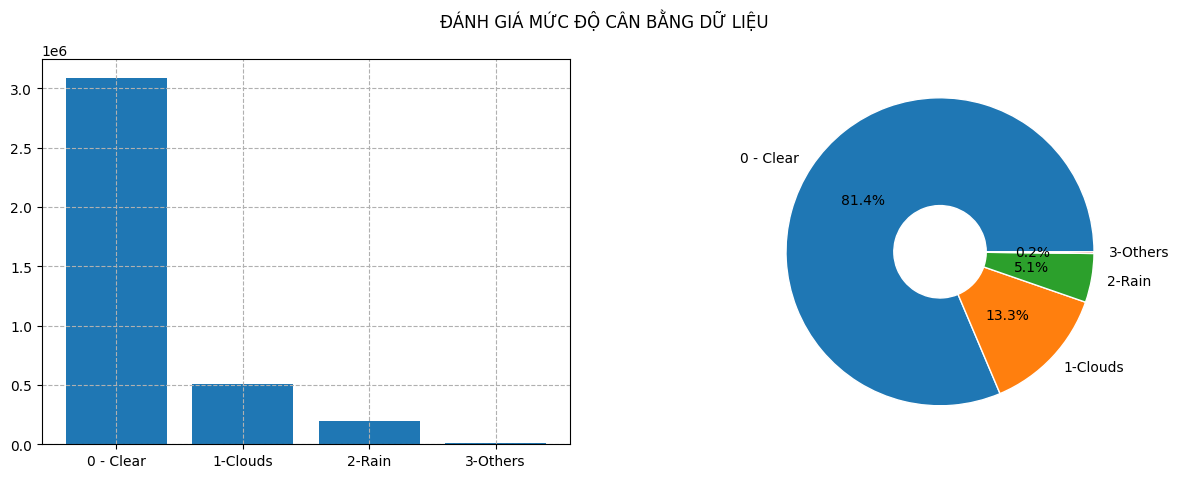

In [ ]:
#Thống kê số lượng bệnh nhân bị bệnh và không bị bệnh (Đánh giá mức độ cân bằng dữ liệu)
kiemtra = y.value_counts()
lb = ['0 - Clear', '1-Clouds', '2-Rain', '3-Others']
print(kiemtra)
#----------------------------------------------
#trực quan hóa số liệu
import matplotlib.pyplot as plt
plt.figure(figsize=(15,5))

#Vẽ biểu đồ cột thể hiện số lượng hồ sơ bị bệnh - không bị bệnh
plt.subplot(1,2,1)
plt.bar(lb,kiemtra.values)
plt.grid(ls='--')

#Vẽ biểu đồ tròn thể hiện tỷ lệ % hồ sơ bị bệnh - ko bị bệnh
plt.subplot(1,2,2)
plt.pie(kiemtra.values, labels=lb,
        autopct='%.1f%%', wedgeprops=dict(width=0.7,edgecolor='w'))

plt.suptitle('ĐÁNH GIÁ MỨC ĐỘ CÂN BẰNG DỮ LIỆU')
plt.show()

### Addressing Data Imbalance with Over-Under Sampling

The previous analysis revealed a significant imbalance in the `weather_group` target variable. To mitigate this, we will use a hybrid over-under sampling technique. This approach combines Synthetic Minority Over-sampling Technique (SMOTE) with an undersampling method (Tomek Links) to both create synthetic samples for minority classes and remove noisy or redundant samples from majority classes, leading to a more balanced dataset for training our model.

In [ ]:
pip install imbalanced-learn

In [ ]:
from imblearn.combine import SMOTETomek

# Initialize SMOTETomek
smotetomek = SMOTETomek(random_state=42)

# Apply the resampling technique to the training data
X_train_resampled, y_train_resampled = smotetomek.fit_resample(X_train, y_train)

print('Shape of X_train after resampling:', X_train_resampled.shape)
print('Shape of y_train after resampling:', y_train_resampled.shape)

Shape of X_train after resampling: (9889418, 11)
Shape of y_train after resampling: (9889418, 1)


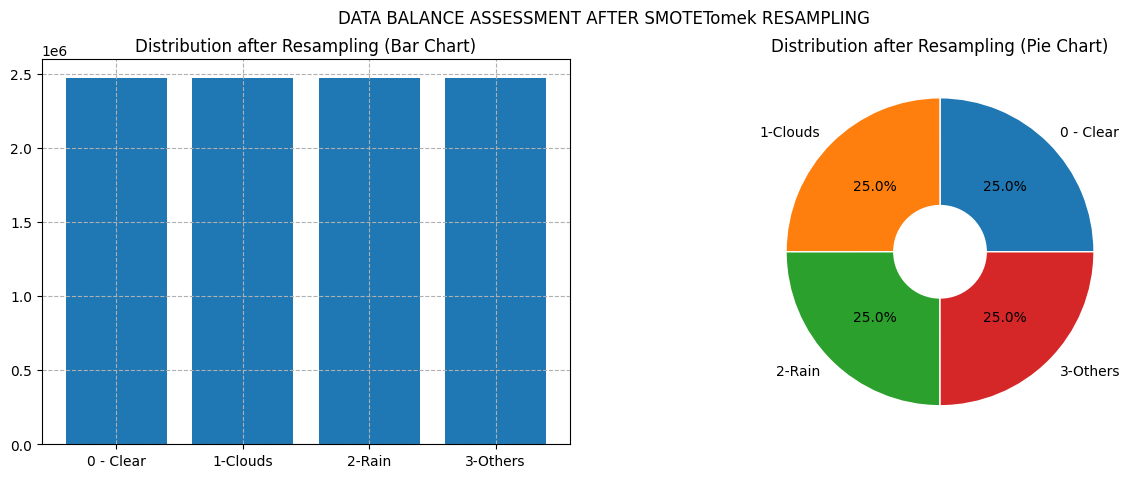

New distribution of weather_group after resampling:
weather_group
2                2472653
1                2472545
0                2472165
3                2472055
Name: count, dtype: int64


In [ ]:
# Visualize the new distribution of the target variable in the resampled training set
resampled_counts = y_train_resampled.value_counts()
lb = ['0 - Clear', '1-Clouds', '2-Rain', '3-Others'] # Using the same labels as before

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.bar(lb, resampled_counts.values)
plt.grid(ls='--')
plt.title('Distribution after Resampling (Bar Chart)')

plt.subplot(1, 2, 2)
plt.pie(resampled_counts.values, labels=lb, autopct='%.1f%%', wedgeprops=dict(width=0.7, edgecolor='w'))
plt.title('Distribution after Resampling (Pie Chart)')

plt.suptitle('DATA BALANCE ASSESSMENT AFTER SMOTETomek RESAMPLING')
plt.show()

print('New distribution of weather_group after resampling:')
print(resampled_counts)

In [ ]:
# RF = RandomForestClassifier(n_estimators=100, random_state=42)
# RF.fit(X_train, y_train)
# acc_train = RF.score(X_train,y_train)
# print('Độ chính xác trên tập huấn luyện:', acc_train, '~', round(acc_train*100,2), '%')

In [ ]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

In [ ]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

acc_train = model.score(X_train, y_train)

print('Độ chính xác trên tập huấn luyện:', acc_train, '~', round(acc_train*100, 2), '%')

Độ chính xác trên tập huấn luyện: 0.8767761548811334 ~ 87.68 %


In [ ]:
y_pred = model.predict(X_test)
acc_test = accuracy_score(y_test,y_pred)

print("Độ chính xác của mô hình RF trên tập Test:", acc_test, ' ~', round(acc_test*100,2), '%')

Độ chính xác của mô hình RF trên tập Test: 0.8775024020427235  ~ 87.75 %


In [ ]:
# y_pred = RF.predict(X_test)
# acc_test = accuracy_score(y_test,y_pred)

# print("Độ chính xác của mô hình RF trên tập Test:", acc_test, ' ~', round(acc_test*100,2), '%')

In [ ]:
import pickle
import os

filename = '/content/drive/MyDrive/Do_an/Model/weather_forecast.sav'
directory = os.path.dirname(filename)

# Create the directory if it doesn't exist
if not os.path.exists(directory):
    os.makedirs(directory)

pickle.dump(model, open(filename, 'wb'))
print('Đã lưu thành công!')

Đã lưu thành công!


In [ ]:
# API_KEY = '614c6943815553c19e55bb9ad160cf28' #Thay thế bằng Khóa API thực tế của bạn
# BASE_URL = 'https://api.openweathermap.org/data/2.5/' #URL cơ sở để thực hiện các yêu cầu API

In [ ]:
# # -------------------------------------------------------
# # 1. LẤY DỮ LIỆU THỰC TẾ TỪ API
# # -------------------------------------------------------
# def get_current_weather(city, lat, lon):
#     url = f"{BASE_URL}weather?lat={lat}&lon={lon}&appid={API_KEY}&units=metric"
#     response = requests.get(url)
#     data = response.json()

#     if response.status_code != 200:
#         print(f"Lỗi: {data.get('message', 'Unknown error')}")
#         return None

#     return {
#         'city'          : data['name'],
#         'country'       : data['sys']['country'],
#         'current_temp'  : round(data['main']['temp'], 2),
#         'feels_like'    : round(data['main']['feels_like'], 2),
#         'temp_min'      : round(data['main']['temp_min'], 2),
#         'temp_max'      : round(data['main']['temp_max'], 2),
#         'humidity'      : data['main']['humidity'],
#         'pressure'      : data['main']['pressure'],
#         'visibility'    : data.get('visibility', 10000),
#         'cloudcover'    : data['clouds']['all'],
#         'wind_speed'    : data['wind']['speed'],
#         'wind_gust'     : data['wind'].get('gust', data['wind']['speed']),
#         'wind_direction': data['wind']['deg'],
#         'description'   : data['weather'][0]['description'],
#     }

In [ ]:
# # -------------------------------------------------------
# # 2. DỰ BÁO PHÂN LOẠI THỜI TIẾT (dùng RF Classifier)
# # -------------------------------------------------------
# def predict_weather_class(weather, model):
#     features = [[
#         weather['current_temp'],
#         weather['temp_min'],
#         weather['temp_max'],
#         weather['humidity'],
#         weather['feels_like'],
#         weather['visibility'],
#         weather['cloudcover'],
#         weather['wind_speed'],
#         weather['wind_gust'],
#         weather['wind_direction'],
#         weather['pressure'],
#     ]]
#     pred = model.predict(features)[0]
#     return LABEL_MAP.get(pred, 'Unknown')

In [ ]:
# def train_rain_model(X, y):
#   X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #split the data into training and testing sets
#   model = RandomForestClassifier(n_estimators=100, random_state=42) #create a random forest classifier model
#   model.fit(X_train, y_train) #train the model

#   y_pred = model.predict(X_test) #make predictions on the test set
#   print("Mean Squared Error for Rain Model")
#   print(mean_squared_error(y_test, y_pred))
#   return model

In [ ]:
# # -------------------------------------------------------
# # 3. DỰ BÁO CÁC CHỈ SỐ 5 BƯỚC TỚI (dùng RF Regressor)
# # -------------------------------------------------------
# def prepare_regression_data(data, feature):
#     X = data[feature].iloc[:-1].values.reshape(-1, 1)
#     y = data[feature].iloc[1:].values
#     return X, y

In [ ]:
# def train_regression_model(X, y):
#     model = RandomForestRegressor(n_estimators=100, random_state=42)
#     model.fit(X, y)
#     return model

In [ ]:
# def predict_future(model, current_value, steps=5):
#     predictions = [current_value]
#     for _ in range(steps):
#         next_val = model.predict(np.array([[predictions[-1]]]))[0]
#         predictions.append(next_val)
#     return predictions[1:]

In [ ]:
# # ============================================================
# # BƯỚC CUỐI: DỰ BÁO THỜI TIẾT THỰC TẾ QUA OPENWEATHERMAP API
# # ============================================================

# # --- Nhãn giải mã (theo thứ tự LabelEncoder đã fit) ---
# LABEL_MAP = {0: 'Clear', 1: 'Clouds', 2: 'Rain', 3: 'Other'}
# timezone = pytz.timezone('Asia/Ho_Chi_Minh')



# # -------------------------------------------------------
# # 4. HIỂN THỊ KẾT QUẢ ĐẦY ĐỦ
# # -------------------------------------------------------
# def weather_view(city):
#     print("=" * 55)
#     print(f"DỰ BÁO THỜI TIẾT THỰC TẾ — {city.upper()}")
#     print("=" * 55)

#     # Lấy dữ liệu hiện tại
#     weather = get_current_weather(city)
#     if weather is None:
#         return


#     now = datetime.now(timezone)
#     base_hour = now.replace(minute=0, second=0, microsecond=0)


#     # Phân loại thời tiết bằng RF Classifier
#     weather_class = predict_weather_class(weather, RF)
#     print(f"\nDự báo loại thời tiết (ML): {weather_class}")

#     # Thông tin hiện tại
#     print(f"\nThành phố : {weather['city']}, {weather['country']}")
#     print(f"Thời điểm : {now.strftime('%d/%m/%Y %H:%M')} (Giờ VN)")
#     print(f"Nhiệt độ   : {weather['current_temp']}°C  "
#           f"(Cảm giác: {weather['feels_like']}°C)")
#     print(f"Min/Max    : {weather['temp_min']}°C / {weather['temp_max']}°C")
#     print(f"Độ ẩm      : {weather['humidity']}%")
#     print(f"Gió        : {weather['wind_speed']} m/s  "
#           f"(Giật: {weather['wind_gust']} m/s)")
#     print(f"Mây che    : {weather['cloudcover']}%")
#     print(f"Tầm nhìn   : {weather['visibility']} m")
#     print(f"Áp suất    : {weather['pressure']} hPa")
#     print(f"Mô tả      : {weather['description'].capitalize()}")

#     # Dự báo 5 bước tới bằng RF Regressor
#     # (Train nhanh trên tập df hiện có)
#     print("\n" + "-" * 55)
#     print("DỰ BÁO 5 KHOẢNG THỜI GIAN TỚI (1 giờ/bước)")
#     print("-" * 55)

#     features_to_forecast = {
#         'Nhiệt độ (°C)'  : ('temperature',  weather['current_temp']),
#         'Độ ẩm (%)'       : ('humidity',      weather['humidity']),
#         'Tốc độ gió (m/s)': ('wind_speed',    weather['wind_speed']),
#     }

#     for label, (col, current_val) in features_to_forecast.items():
#         X_r, y_r = prepare_regression_data(df, col)
#         reg_model = train_regression_model(X_r, y_r)
#         preds = predict_future(reg_model, current_val, steps=5)

#         print(f"\n  {label}")
#         print(f"  Hiện tại: {round(current_val, 2)}")
#         for i, val in enumerate(preds, 1):
#             t = (base_hour + timedelta(hours=i)).strftime('%H:%M')
#             print(f"    +{i} giờ ({t}): {round(val, 2)}")

#     print("\n" + "=" * 55)
#     print("Dự báo hoàn tất!")
#     print("=" * 55)

# # -------------------------------------------------------
# # 5. CHẠY CHƯƠNG TRÌNH
# # -------------------------------------------------------
# city_input = input("Nhập tên thành phố (VD: Hanoi, Ho Chi Minh City): ")
# weather_view(city_input)